# Weather Data Collection — Jeju Island

Pulls historical hourly weather data from Open-Meteo (free, no API key) for two locations:
- **Jeju-Si** (33.50°N, 126.53°E) — north coast
- **Seogwipo-Si** (33.25°N, 126.57°E) — south coast

The island's central mountain (Mt. Hallasan, 1,950m) creates distinct microclimates on each side.

**Period:** 2021-01-01 to 2022-12-31 (matching the EV charging dataset)  
**Output:**
- `data/interim/jeju_weather_hourly.parquet` — raw weather, one row per city per hour
- `data/processed/ev_cleaned_hourly_weather.parquet` — cleaned EV data joined with weather

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import openmeteo_requests
import requests_cache
from retry_requests import retry

sns.set_theme(style='whitegrid', palette='muted')

# Find project root
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

INTERIM_DIR  = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

WEATHER_PATH = INTERIM_DIR / 'jeju_weather_hourly.parquet'
EV_CLEAN_PATH = PROCESSED_DIR / 'ev_cleaned_hourly.parquet'
OUT_PATH = PROCESSED_DIR / 'ev_cleaned_hourly_weather.parquet'

# Time range matching the EV dataset
START_DATE = '2021-01-01'
END_DATE   = '2022-12-31'

# Weather station coordinates
LOCATIONS = {
    'Jeju-Si':      {'lat': 33.50, 'lon': 126.53},
    'Seogwipo-Si':  {'lat': 33.25, 'lon': 126.57},
}

print(f'Project root: {PROJECT_ROOT}')
print(f'Period: {START_DATE} → {END_DATE}')

Project root: /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project
Period: 2021-01-01 → 2022-12-31


## 1. Fetch Weather Data from Open-Meteo

Variables pulled:
- `temperature_2m` — Air temperature at 2m height (°C)
- `relative_humidity_2m` — Relative humidity at 2m height (%)
- `precipitation` — Total precipitation in the hour (mm)
- `wind_speed_10m` — Wind speed at 10m height (km/h)
- `cloud_cover` — Total cloud cover (%)

In [2]:
# Setup cached session so re-runs don't hit the API again
cache_session = requests_cache.CachedSession('.openmeteo_cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
om = openmeteo_requests.Client(session=retry_session)

HOURLY_VARIABLES = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'wind_speed_10m',
    'cloud_cover',
]

frames = []

for city, coord in LOCATIONS.items():
    print(f'Fetching weather for {city} ({coord["lat"]}, {coord["lon"]})...')

    params = {
        'latitude':  coord['lat'],
        'longitude': coord['lon'],
        'start_date': START_DATE,
        'end_date':   END_DATE,
        'hourly': HOURLY_VARIABLES,
        'timezone': 'Asia/Seoul',
    }

    responses = om.weather_api(
        'https://archive-api.open-meteo.com/v1/archive',
        params=params
    )
    response = responses[0]

    hourly = response.Hourly()
    timestamps = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit='s', utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit='s', utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive='left'
    ).tz_convert('Asia/Seoul').tz_localize(None)

    weather_df = pd.DataFrame({
        'timestamp_hour':      timestamps,
        'city':                city,
        'temperature_c':       hourly.Variables(0).ValuesAsNumpy(),
        'humidity_pct':        hourly.Variables(1).ValuesAsNumpy(),
        'precipitation_mm':    hourly.Variables(2).ValuesAsNumpy(),
        'wind_speed_kmh':      hourly.Variables(3).ValuesAsNumpy(),
        'cloud_cover_pct':     hourly.Variables(4).ValuesAsNumpy(),
    })

    frames.append(weather_df)
    print(f'  → {len(weather_df):,} rows')

weather = pd.concat(frames, ignore_index=True)
print(f'\nTotal weather rows: {len(weather):,}')
print(f'Date range: {weather["timestamp_hour"].min()} → {weather["timestamp_hour"].max()}')
weather.head()

Fetching weather for Jeju-Si (33.5, 126.53)...
  → 17,520 rows
Fetching weather for Seogwipo-Si (33.25, 126.57)...
  → 17,520 rows

Total weather rows: 35,040
Date range: 2021-01-01 00:00:00 → 2022-12-31 23:00:00


,timestamp_hour,city,temperature_c,humidity_pct,precipitation_mm,wind_speed_kmh,cloud_cover_pct
0,2021-01-01 00:00:00,Jeju-Si,3.3705,61.975224,0.0,27.492311,100.0
1,2021-01-01 01:00:00,Jeju-Si,3.1205,63.079113,0.0,25.984919,100.0
2,2021-01-01 02:00:00,Jeju-Si,3.2705,61.490509,0.0,25.233404,100.0
3,2021-01-01 03:00:00,Jeju-Si,3.3205,61.273857,0.0,23.177401,100.0
4,2021-01-01 04:00:00,Jeju-Si,3.3205,61.045650,0.0,21.945240,99.0


## 2. Inspect & Validate Weather Data

In [3]:
print('Null counts:')
print(weather.isnull().sum())
print(f'\nRows per city:')
print(weather['city'].value_counts())

weather_cols = ['temperature_c', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmh', 'cloud_cover_pct']
print('\nSummary stats:')
print(weather[weather_cols].describe().round(2))

Null counts:
timestamp_hour      0
city                0
temperature_c       0
humidity_pct        0
precipitation_mm    0
wind_speed_kmh      0
cloud_cover_pct     0
dtype: int64

Rows per city:
city
Jeju-Si        17520
Seogwipo-Si    17520
Name: count, dtype: int64

Summary stats:
       temperature_c  humidity_pct  precipitation_mm  wind_speed_kmh  \
count       35040.00      35040.00          35040.00        35040.00   
mean           16.10         77.78              0.26           12.07   
std             8.17         14.72              1.15            7.81   
min            -4.55         19.61              0.00            0.00   
25%             9.75         68.32              0.00            5.80   
50%            16.47         79.29              0.00           10.70   
75%            23.42         89.44              0.00           16.75   
max            33.72        100.00             42.10           57.19   

       cloud_cover_pct  
count         35040.00  
mean            

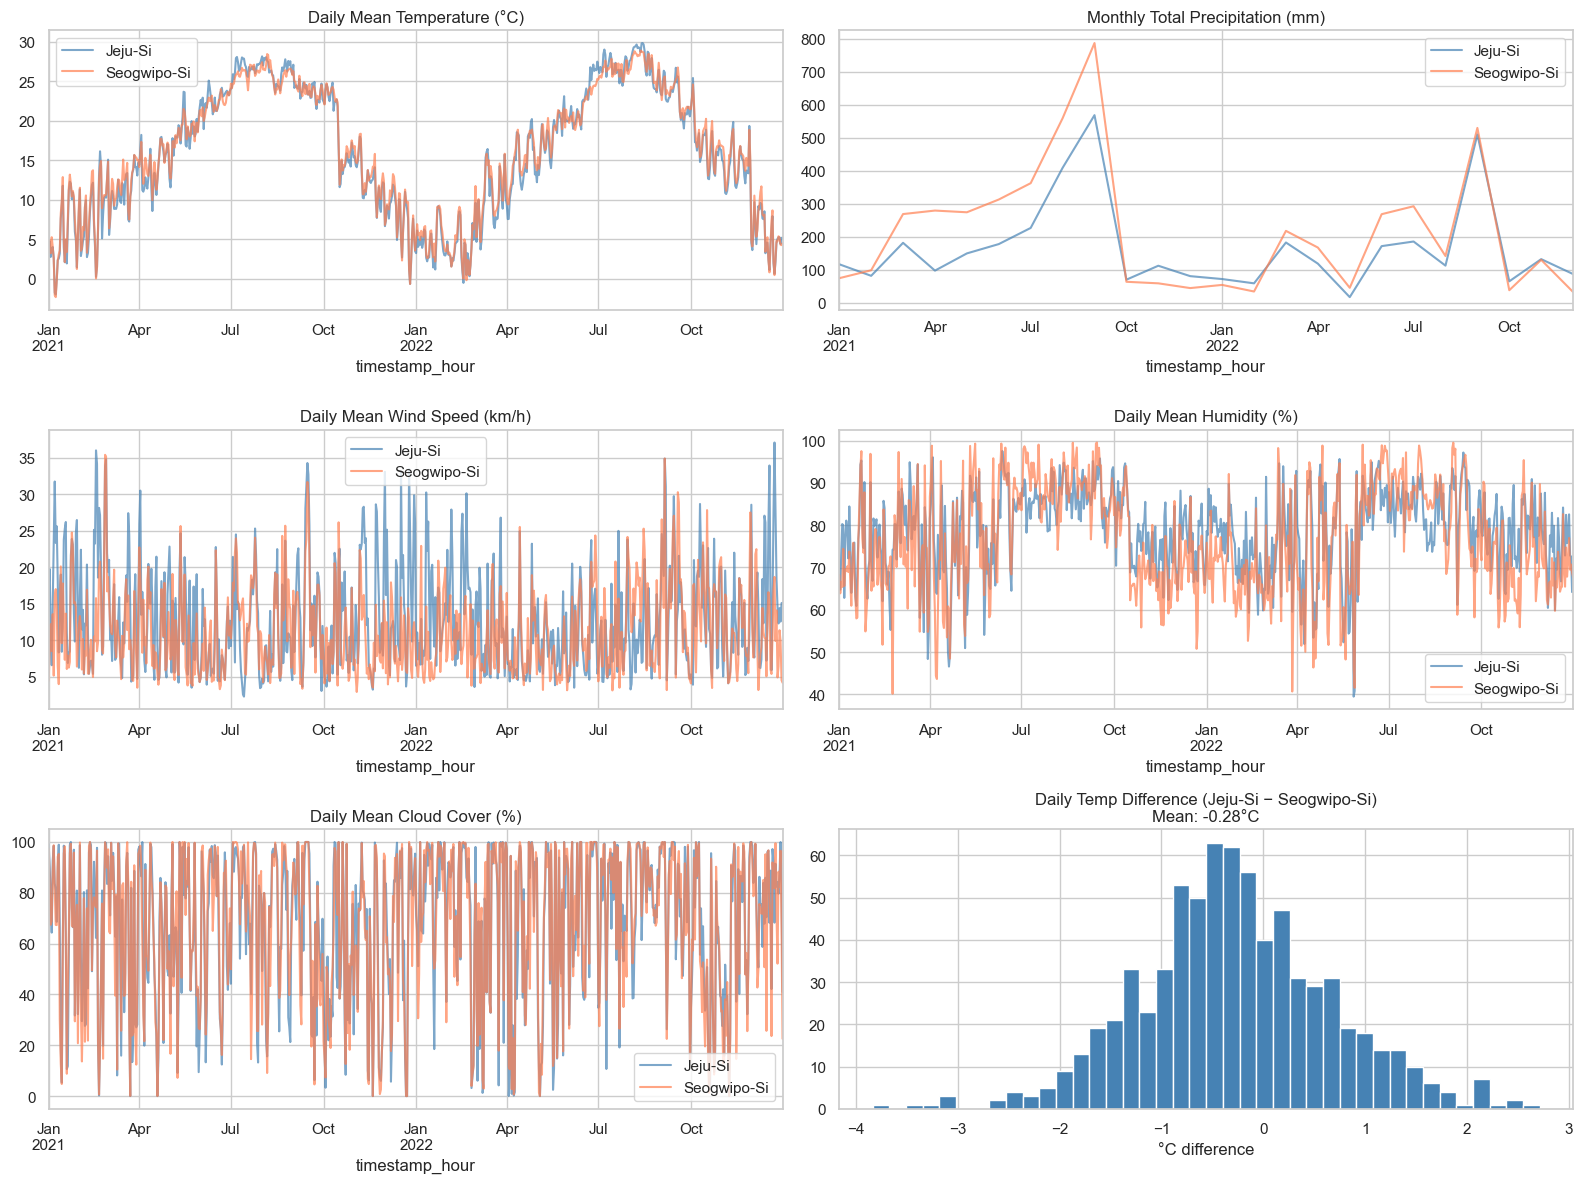

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for city, color in [('Jeju-Si', 'steelblue'), ('Seogwipo-Si', 'coral')]:
    w = weather[weather['city'] == city].set_index('timestamp_hour')

    # Temperature — daily mean
    w['temperature_c'].resample('D').mean().plot(ax=axes[0, 0], alpha=0.7, color=color, label=city)
    axes[0, 0].set_title('Daily Mean Temperature (°C)')
    axes[0, 0].legend()

    # Precipitation — monthly total
    w['precipitation_mm'].resample('ME').sum().plot(ax=axes[0, 1], alpha=0.7, color=color, label=city)
    axes[0, 1].set_title('Monthly Total Precipitation (mm)')
    axes[0, 1].legend()

    # Wind speed — daily mean
    w['wind_speed_kmh'].resample('D').mean().plot(ax=axes[1, 0], alpha=0.7, color=color, label=city)
    axes[1, 0].set_title('Daily Mean Wind Speed (km/h)')
    axes[1, 0].legend()

    # Humidity — daily mean
    w['humidity_pct'].resample('D').mean().plot(ax=axes[1, 1], alpha=0.7, color=color, label=city)
    axes[1, 1].set_title('Daily Mean Humidity (%)')
    axes[1, 1].legend()

    # Cloud cover — daily mean
    w['cloud_cover_pct'].resample('D').mean().plot(ax=axes[2, 0], alpha=0.7, color=color, label=city)
    axes[2, 0].set_title('Daily Mean Cloud Cover (%)')
    axes[2, 0].legend()

# Difference between cities — temperature
jeju_temp = weather[weather['city'] == 'Jeju-Si'].set_index('timestamp_hour')['temperature_c'].resample('D').mean()
seo_temp = weather[weather['city'] == 'Seogwipo-Si'].set_index('timestamp_hour')['temperature_c'].resample('D').mean()
temp_diff = (jeju_temp - seo_temp).dropna()
axes[2, 1].hist(temp_diff, bins=40, color='steelblue', edgecolor='white')
axes[2, 1].set_title(f'Daily Temp Difference (Jeju-Si − Seogwipo-Si)\nMean: {temp_diff.mean():.2f}°C')
axes[2, 1].set_xlabel('°C difference')

plt.tight_layout()
plt.show()

## 3. Save Raw Weather Data

In [5]:
# Add derived features
weather['is_raining'] = weather['precipitation_mm'] > 0

# Downcast for efficiency
for col in ['temperature_c', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmh', 'cloud_cover_pct']:
    weather[col] = weather[col].astype('float32')

weather.to_parquet(WEATHER_PATH, index=False)
print(f'Saved weather → {WEATHER_PATH}')
print(f'Shape: {weather.shape}')

Saved weather → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/data/interim/jeju_weather_hourly.parquet
Shape: (35040, 8)


## 4. Join Weather to EV Dataset

Each station is matched to its city's weather using the `city` column.  
Stations on Udo Island → Jeju-Si weather (right off the NE coast).  
Station on Chuja Island → Jeju-Si weather (closest major station).

In [6]:
ev = pd.read_parquet(EV_CLEAN_PATH)
print(f'EV dataset: {ev.shape[0]:,} rows × {ev.shape[1]} cols')
print(f'Unique cities in EV data: {ev["city"].unique()}')

# Standardize city names to match weather data
# EV data has title-case from cleaning: 'Jeju-Si', 'Seogwipo-Si'
weather_wide = weather.pivot_table(
    index='timestamp_hour',
    columns='city',
    values=['temperature_c', 'humidity_pct', 'precipitation_mm',
            'wind_speed_kmh', 'cloud_cover_pct', 'is_raining']
)

# Flatten to city-specific columns for merge
jeju_weather = weather[weather['city'] == 'Jeju-Si'].drop(columns='city').copy()
seo_weather = weather[weather['city'] == 'Seogwipo-Si'].drop(columns='city').copy()

weather_cols = ['temperature_c', 'humidity_pct', 'precipitation_mm',
                'wind_speed_kmh', 'cloud_cover_pct', 'is_raining']

# Map city to weather — stations not in Seogwipo-Si get Jeju-Si weather
ev_jeju = ev[ev['city'] != 'Seogwipo-Si'].merge(
    jeju_weather, on='timestamp_hour', how='left'
)
ev_seo = ev[ev['city'] == 'Seogwipo-Si'].merge(
    seo_weather, on='timestamp_hour', how='left'
)

ev_weather = pd.concat([ev_jeju, ev_seo], ignore_index=True)
ev_weather = ev_weather.sort_values(['customer_id', 'timestamp_hour']).reset_index(drop=True)

print(f'\nJoined dataset: {ev_weather.shape[0]:,} rows × {ev_weather.shape[1]} cols')
print(f'New columns: {weather_cols}')
print(f'\nWeather null check after join:')
print(ev_weather[weather_cols].isnull().sum())

EV dataset: 10,249,200 rows × 39 cols
Unique cities in EV data: <StringArray>
['Seogwipo-Si', 'Jeju-Si']
Length: 2, dtype: string

Joined dataset: 10,249,200 rows × 45 cols
New columns: ['temperature_c', 'humidity_pct', 'precipitation_mm', 'wind_speed_kmh', 'cloud_cover_pct', 'is_raining']

Weather null check after join:
temperature_c       0
humidity_pct        0
precipitation_mm    0
wind_speed_kmh      0
cloud_cover_pct     0
is_raining          0
dtype: int64


## 5. Verification

In [7]:
# Row count should match original EV dataset
assert len(ev_weather) == len(ev), f'Row count mismatch: {len(ev_weather)} vs {len(ev)}'
print(f'[PASS] Row count matches: {len(ev_weather):,}')

# Spot check: different weather for different cities on the same hour
sample_hour = ev_weather['timestamp_hour'].iloc[0]
sample = ev_weather[ev_weather['timestamp_hour'] == sample_hour]
city_temps = sample.groupby('city')['temperature_c'].first()
print(f'\n[CHECK] Temperature at {sample_hour}:')
for city, temp in city_temps.items():
    print(f'  {city}: {temp:.1f}°C')

# All original columns still present
original_cols = set(ev.columns)
missing = original_cols - set(ev_weather.columns)
print(f'\n[{"PASS" if not missing else "FAIL"}] Original columns preserved: {"all present" if not missing else missing}')

print(f'\nFinal dtypes for weather columns:')
print(ev_weather[weather_cols].dtypes)

[PASS] Row count matches: 10,249,200

[CHECK] Temperature at 2021-01-01 00:00:00:
  Jeju-Si: 3.4°C
  Seogwipo-Si: 2.8°C

[PASS] Original columns preserved: all present

Final dtypes for weather columns:
temperature_c       float32
humidity_pct        float32
precipitation_mm    float32
wind_speed_kmh      float32
cloud_cover_pct     float32
is_raining             bool
dtype: object


## 6. Save Joined Dataset

In [8]:
ev_weather.to_parquet(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')
print(f'Shape: {ev_weather.shape[0]:,} rows × {ev_weather.shape[1]} cols')

size_mb = OUT_PATH.stat().st_size / 1e6
print(f'Size: {size_mb:.1f} MB')

Saved → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/data/processed/ev_cleaned_hourly_weather.parquet
Shape: 10,249,200 rows × 45 cols
Size: 112.7 MB
